In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

from prophet import Prophet

In [2]:
df = pd.read_csv("covid_19_clean_complete.csv")

df.head()

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa


In [3]:
# Convert date
df['Date'] = pd.to_datetime(df['Date'])

# Group by date
global_data = df.groupby('Date')[['Confirmed', 'Deaths', 'Recovered']].sum().reset_index()

global_data.head()

,Date,Confirmed,Deaths,Recovered
0,2020-01-22,555,17,28
1,2020-01-23,654,18,30
2,2020-01-24,941,26,36
3,2020-01-25,1434,42,39
4,2020-01-26,2118,56,52


In [4]:
print(global_data.describe())

                      Date     Confirmed         Deaths     Recovered
count                  188  1.880000e+02     188.000000  1.880000e+02
mean   2020-04-24 12:00:00  4.406960e+06  230770.760638  2.066001e+06
min    2020-01-22 00:00:00  5.550000e+02      17.000000  2.800000e+01
25%    2020-03-08 18:00:00  1.121910e+05    3935.000000  6.044125e+04
50%    2020-04-24 12:00:00  2.848733e+06  204190.000000  7.847840e+05
75%    2020-06-10 06:00:00  7.422046e+06  418634.500000  3.416396e+06
max    2020-07-27 00:00:00  1.648048e+07  654036.000000  9.468087e+06
std                    NaN  4.757988e+06  217929.094183  2.627976e+06


**VISUALIZATION**

In [6]:
fig = px.line(global_data, x='Date', y='Confirmed',   #Confirmed Cases Trend
              title='Global Confirmed Cases Over Time')
fig.show()

In [7]:
#Death Cases
fig = px.line(global_data, x='Date', y='Deaths',
              title='Global Death Cases Over Time')
fig.show()

In [8]:
#Recovered Cases
fig = px.line(global_data, x='Date', y='Recovered',
              title='Global Recovered Cases Over Time')
fig.show()

In [9]:
#Growth Rate Analysis
global_data['New Cases'] = global_data['Confirmed'].diff()

fig = px.line(global_data, x='Date', y='New Cases',
              title='Daily New Cases')
fig.show()

In [11]:
#Prepare Data for Prophet
prophet_df = global_data[['Date', 'Confirmed']]
prophet_df.columns = ['ds', 'y']

In [12]:
#Train Model
model = Prophet()
model.fit(prophet_df)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [13]:
#Future Prediction (7 Days)
future = model.make_future_dataframe(periods=7)
forecast = model.predict(future)

forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
190,2020-07-30,1.674392e+07,1.663956e+07,1.684990e+07
191,2020-07-31,1.695911e+07,1.684986e+07,1.706665e+07
192,2020-08-01,1.716677e+07,1.706130e+07,1.728094e+07
193,2020-08-02,1.736430e+07,1.725855e+07,1.748081e+07
194,2020-08-03,1.755889e+07,1.744239e+07,1.768139e+07


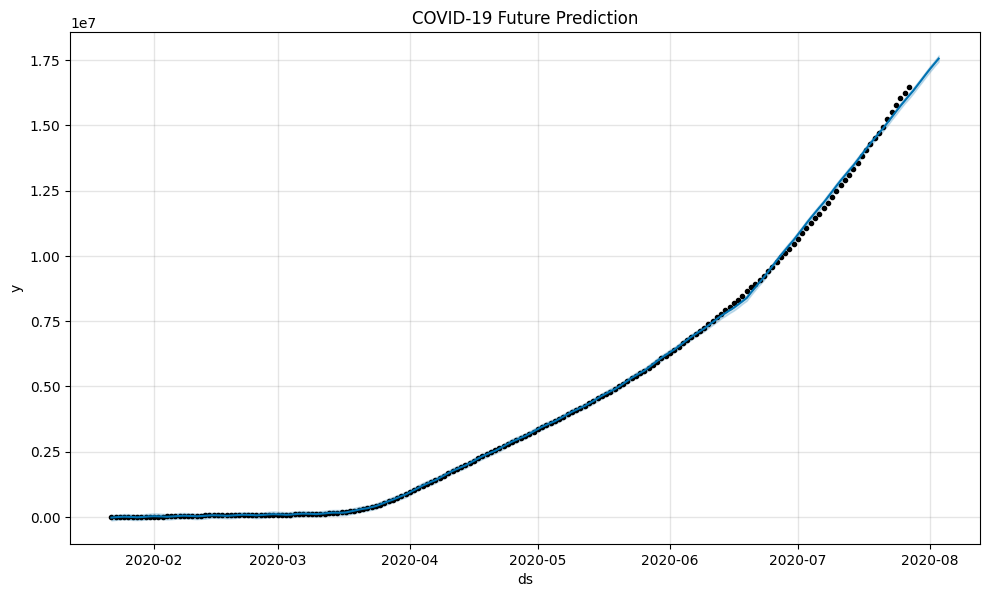

In [14]:
#Visualization of Prediction
model.plot(forecast)
plt.title("COVID-19 Future Prediction")
plt.show()

In [16]:
#Interactive Forecast Plot
from prophet.plot import plot_plotly

fig = plot_plotly(model, forecast)
fig.show()

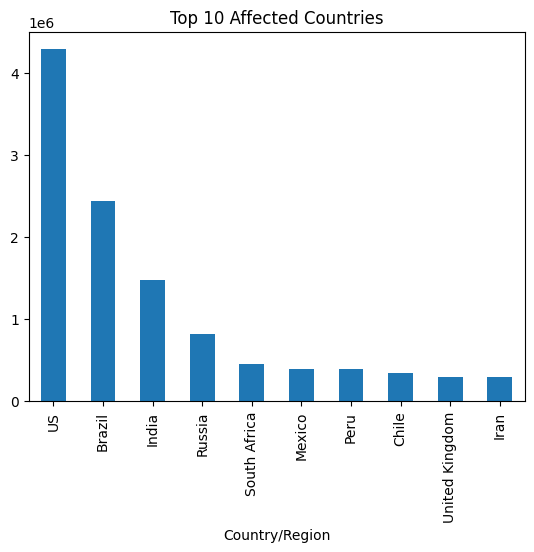

In [17]:
# Top 10 Affected Countries
country_data = df.groupby('Country/Region')['Confirmed'].max().sort_values(ascending=False).head(10)

country_data.plot(kind='bar', title="Top 10 Affected Countries")
plt.show()

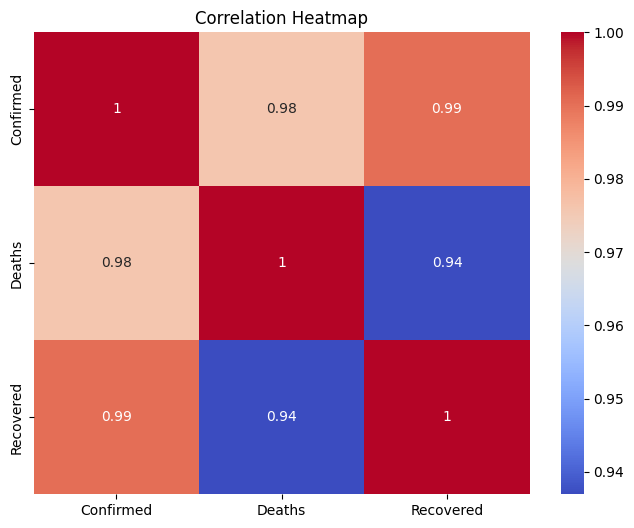

In [18]:
#Correlation Heatmap
import seaborn as sns
import matplotlib.pyplot as plt

corr = global_data[['Confirmed', 'Deaths', 'Recovered']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [19]:
#World Map (Choropleth Map)
import plotly.express as px

latest = df[df['Date'] == df['Date'].max()]

fig = px.choropleth(latest,
                    locations="Country/Region",
                    locationmode="country names",
                    color="Confirmed",
                    hover_name="Country/Region",
                    color_continuous_scale="Reds",
                    title="Worldwide COVID-19 Cases")

fig.show()

In [20]:
#Animated Spread Map
fig = px.choropleth(df,
                    locations="Country/Region",
                    locationmode="country names",
                    color="Confirmed",
                    animation_frame=df['Date'].astype(str),
                    title="COVID-19 Spread Over Time")

fig.show()
